1. The Setup (Imports)

In [4]:
import sys
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from ipywidgets import fixed

# Add the 'src' directory to the path so we can import our modules
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from utils import load_data

# Load the data
X_train, y_train, X_test = load_data()

print(f"Training Samples: {X_train.shape[0]}")
print(f"Test Samples: {X_test.shape[0]}")

Loading data from c:\Users\ANKRI\Desktop\Q1\ELEN0062-1\Project3\Football-pass-prediction\data\raw...
Training Samples: 8686
Test Samples: 3000


2. The Visualization Function

C:\Users\ANKRI\AppData\Local\Temp\ipykernel_1084\2537407492.py:40: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  receiver_id = int(y_data.loc[pass_id])


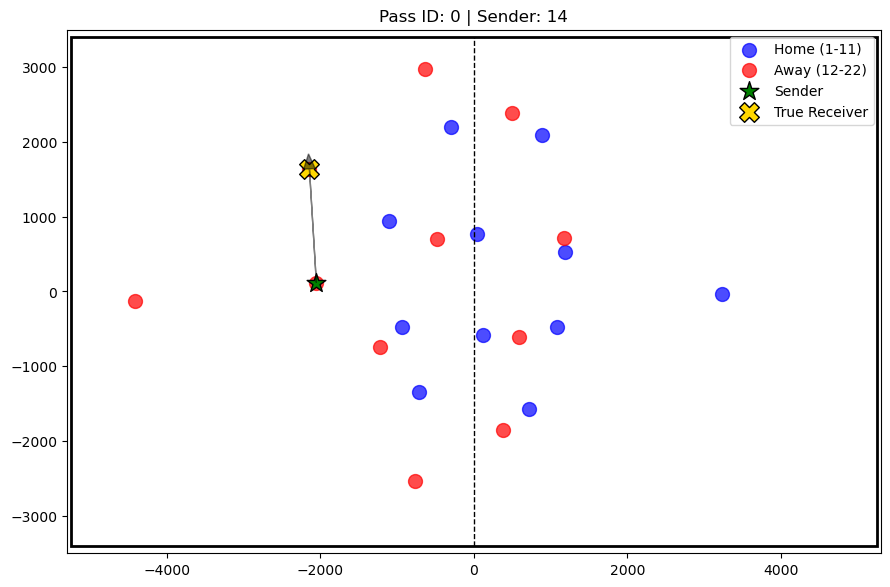

In [5]:
def plot_pass(pass_id, X_data, y_data=None):
    """
    Visualizes a specific pass on the football pitch.
    """
    # Extract the specific sample
    sample = X_data.loc[pass_id]
    sender_id = int(sample['sender_id'])
    
    # Setup the pitch (Dimensions in cm)
    fig, ax = plt.subplots(figsize=(10.5, 6.8)) # Scaled to match 105x68 aspect ratio
    ax.set_xlim(-5300, 5300)
    ax.set_ylim(-3500, 3500)
    ax.set_title(f"Pass ID: {pass_id} | Sender: {sender_id}")
    
    # Draw Pitch Boundary
    pitch = patches.Rectangle((-5250, -3400), 10500, 6800, fill=False, color="black", linewidth=2)
    ax.add_patch(pitch)
    
    # Center Line (optional cosmetic)
    ax.plot([0, 0], [-3400, 3400], color="black", linewidth=1, linestyle="--")

    # --- Plot Players ---
    # Home Team (1-11)
    home_x = [sample[f'x_{i}'] for i in range(1, 12)]
    home_y = [sample[f'y_{i}'] for i in range(1, 12)]
    ax.scatter(home_x, home_y, c='blue', label='Home (1-11)', s=100, alpha=0.7)

    # Away Team (12-22)
    away_x = [sample[f'x_{i}'] for i in range(12, 23)]
    away_y = [sample[f'y_{i}'] for i in range(12, 23)]
    ax.scatter(away_x, away_y, c='red', label='Away (12-22)', s=100, alpha=0.7)

    # --- Highlight Key Actors ---
    # Sender
    s_x, s_y = sample[f'x_{sender_id}'], sample[f'y_{sender_id}']
    ax.scatter(s_x, s_y, c='green', s=200, edgecolors='black', label='Sender', marker='*')
    
    # Receiver (if target is provided)
    if y_data is not None:
        receiver_id = int(y_data.loc[pass_id])
        r_x, r_y = sample[f'x_{receiver_id}'], sample[f'y_{receiver_id}']
        ax.scatter(r_x, r_y, c='gold', s=200, edgecolors='black', label='True Receiver', marker='X')
        
        # Draw Arrow
        ax.arrow(s_x, s_y, r_x - s_x, r_y - s_y, head_width=150, head_length=200, fc='k', ec='k', alpha=0.5)

    ax.legend(loc='upper right')
    plt.show()

# --- Try it out! ---
# Change the ID to see different passes
plot_pass(0, X_train, y_train)

3. What to Look For (Analysis)

In [6]:
from ipywidgets import interact, IntSlider

interact(plot_pass, 
         pass_id=IntSlider(min=0, max=100, step=1, value=0), 
         X_data=fixed(X_train), 
         y_data=fixed(y_train));

interactive(children=(IntSlider(value=0, description='pass_id'), Output()), _dom_classes=('widget-interact',))